<a href="https://colab.research.google.com/github/hiltonsnascimento-cpu/Python/blob/main/files_uploaded.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#==============================================================================
#                   Importa arquivos da pasta do Pc
#==============================================================================
from  google.colab import files
uploaded = files.upload()

Saving vendas_googlecolab.csv to vendas_googlecolab.csv


In [9]:
#==============================================================================
#                   importar as bibliotecas
#==============================================================================
import pandas as pd
import matplotlib.pyplot as plt


In [11]:
print("Formato(linhas,colunaas)", df.shape)
print("Tipos de cada coluna")
print(df.dtypes)

Formato(linhas,colunaas) (30, 6)
Tipos de cada coluna
vendedor            object
regiao              object
produto             object
valor              float64
data        datetime64[ns]
mes              period[M]
dtype: object


In [12]:
#==============================================================================
#                   Gerar tabela com data
#==============================================================================
df = pd.read_csv("vendas_googlecolab.csv")
df.head()

,vendedor,regiao,produto,valor,data
0,Ana,Sudeste,Notebook,3200.0,2026-01-05
1,Ana,Sudeste,Mouse,89.9,2026-01-12
2,Ana,Sul,Teclado,150.0,2026-01-20
3,Bruno,Nordeste,Monitor,890.0,2026-01-08
4,Bruno,Nordeste,Notebook,3400.0,2026-01-15


In [13]:
#==============================================================================
#                   Gerar tabela com data sem o dia
#==============================================================================
df['data'] = pd.to_datetime(df['data'])
df['mes'] = df['data'].dt.to_period('M')
df.head()

,vendedor,regiao,produto,valor,data,mes
0,Ana,Sudeste,Notebook,3200.0,2026-01-05,2026-01
1,Ana,Sudeste,Mouse,89.9,2026-01-12,2026-01
2,Ana,Sul,Teclado,150.0,2026-01-20,2026-01
3,Bruno,Nordeste,Monitor,890.0,2026-01-08,2026-01
4,Bruno,Nordeste,Notebook,3400.0,2026-01-15,2026-01


In [17]:
#==============================================================================
#                 Analise de Dados do melhor e pior Vendedor
#==============================================================================
Total_por_vendedor = df.groupby('vendedor')['valor'].sum().sort_values(ascending=False)
melhor_vendedor = Total_por_vendedor.idxmax()
pior_vendedor = Total_por_vendedor.idxmin()
print("Total por vendedor: ")
print(Total_por_vendedor)
print("")
print(f"Melhor vendedor: {melhor_vendedor} (R${Total_por_vendedor.max():.2f})")
print(f"Pior vendedor: {pior_vendedor} (R${Total_por_vendedor.min():.2f})")

Total por vendedor: 
vendedor
Bruno     8572.0
Carla     8409.9
Elaine    5920.0
Ana       5219.9
Diego     4969.0
Name: valor, dtype: float64

Melhor vendedor: Bruno (R$8572.00)
Pior vendedor: Diego (R$4969.00)


In [18]:
#==============================================================================
#                     Melhor e pior região
#==============================================================================
Total_por_regiao = df.groupby('regiao')['valor'].sum().sort_values(ascending=False)
melhor_regiao = Total_por_regiao.idxmax()
pior_regiao = Total_por_regiao.idxmin()
print("Total por região: ", Total_por_regiao)
print("")
print(f"Região com Maior Venda: {melhor_regiao} (R${Total_por_regiao.max():.2f})")
print(f"Região com Menor Venda: {pior_regiao} (R${Total_por_regiao.min():.2f}))

Total por região:  regiao
Sudeste         13189.9
Norte            7059.0
Nordeste         6482.0
Sul              5304.9
Centro-Oeste     1055.0
Name: valor, dtype: float64

Região com Maior Venda: Sudeste (R$13189.90)
Região com Menor Venda: Centro-Oeste (R$1055.00)


In [19]:
faturanto_total = df['valor'].sum()
ticket_medio = df['valor'].mean()

print(f"🤑Faturamento Total: R${faturanto_total:.2f}💰")
print(f"💸Ticket Médio: R${ticket_medio:.2f}")

🤑Faturamento Total: R$33090.80💰
💸Ticket Médio: R$1103.03


In [31]:
media_por_vendedor = df.groupby('vendedor')['valor'].mean().sort_values(ascending=False)
faturamento_por_mes = df.groupby('mes')['valor'].sum().sort_index()
#01/2026 -------> Jan/2026
faturamento_por_mes.index = faturamento_por_mes.index.strftime('%b-%Y')
print(media_por_vendedor)
print()
print(faturamento_por_mes)


vendedor
Bruno     1428.666667
Carla     1201.414286
Diego      993.800000
Elaine     986.666667
Ana        869.983333
Name: valor, dtype: float64

mes
Jan-2026    18833.8
Feb-2026    14257.0
Name: valor, dtype: float64


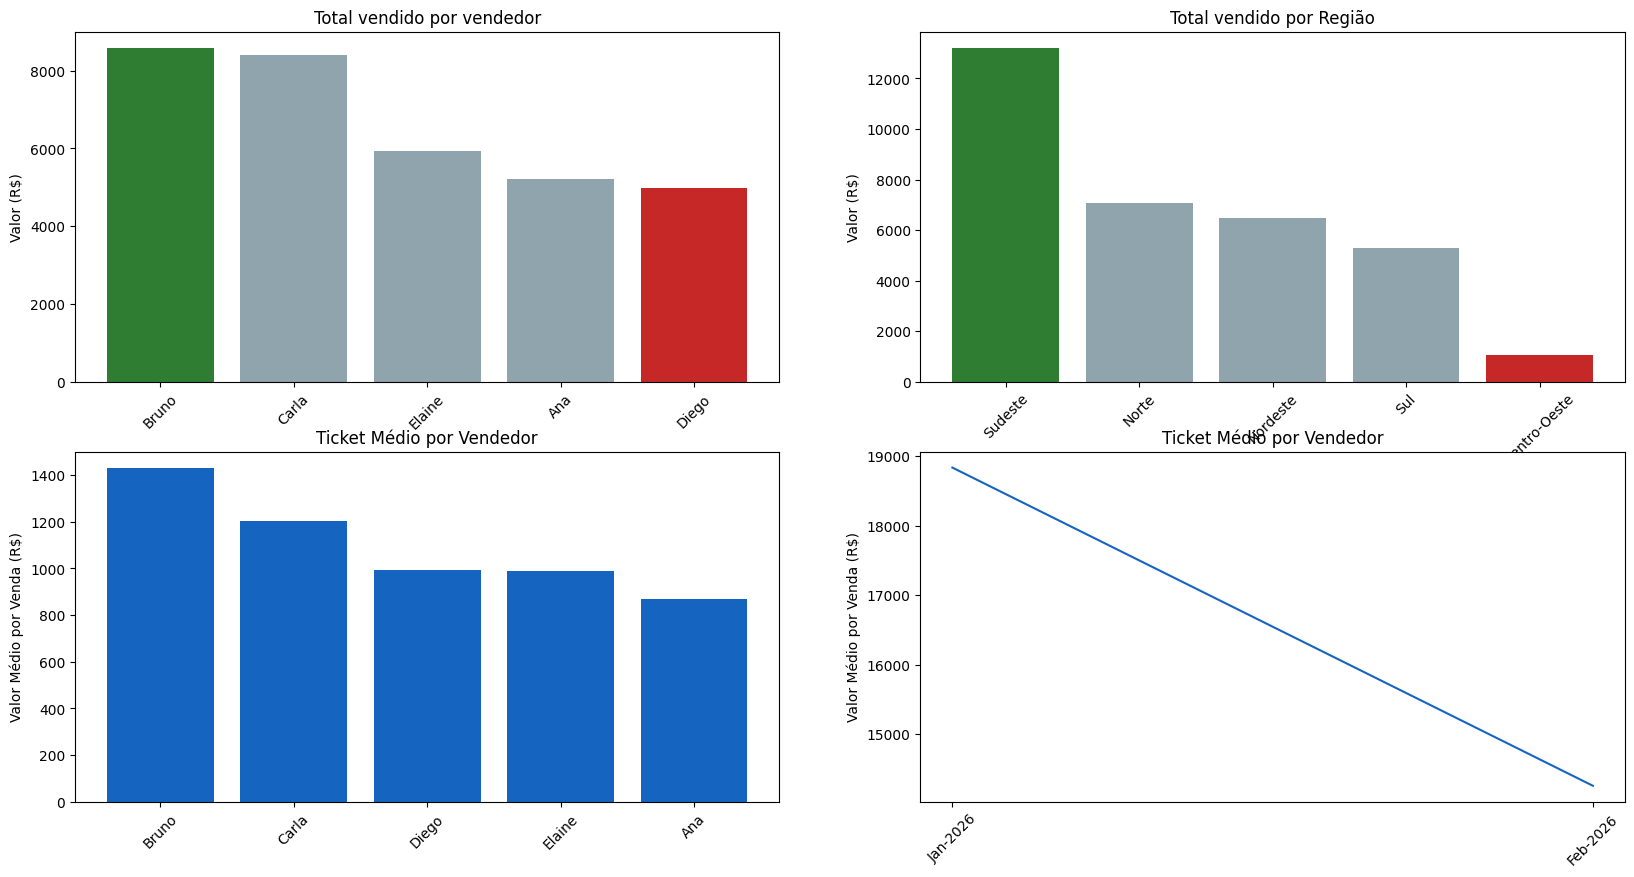

In [30]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 10))

#==============================================================================
#                 Gráfico 1, Total vendido por vendedor
#==============================================================================
cores_vendedor = [
    '#2E7D32' if vendedor == melhor_vendedor else '#C62828' if vendedor == pior_vendedor else '#90A4AE'
    for vendedor in Total_por_vendedor.index
]
ax1.bar(Total_por_vendedor.index, Total_por_vendedor.values,color=cores_vendedor)
ax1.set_title('Total vendido por vendedor')
ax1.set_ylabel('Valor (R$)')
ax1.tick_params(axis='x', rotation=45)

#==============================================================================
#                 Gráfico 2 Total por Região
#==============================================================================
cores_regiao = [
    '#2E7D32' if regiao == melhor_regiao else '#C62828' if regiao == pior_regiao else '#90A4AE'
    for regiao in Total_por_regiao.index
]
ax2.bar(Total_por_regiao.index, Total_por_regiao.values,color=cores_regiao)
ax2.set_title('Total vendido por Região')
ax2.set_ylabel('Valor (R$)')
ax2.tick_params(axis='x', rotation=45)

#==============================================================================
#                 Gráfico 3 Ticket médio por vendedor
#==============================================================================
ax3.bar(media_por_vendedor.index, media_por_vendedor.values,color="#1565c0")
ax3.set_title('Ticket Médio por Vendedor')
ax3.set_ylabel('Valor Médio por Venda (R$)')
ax3.tick_params(axis='x', rotation=45)

#==============================================================================
#                 Gráfico 4 Faturamento Total por mês
#==============================================================================
ax4.plot(faturamento_por_mes.index, faturamento_por_mes.values,color="#1565c0")
ax4.set_title('Ticket Médio por Vendedor')
ax4.set_ylabel('Valor Médio por Venda (R$)')
ax4.tick_params(axis='x', rotation=45)